# FakeCLR Architecture: Deep Dive Analysis
### FFHQ to Panda Transfer Learning

This notebook evaluates the **FakeCLR** (Fake Contrastive Learning Representation) architecture. FakeCLR introduces contrastive loss applied to perturbed fake images to improve the representations learned by the discriminator, stabilizing training on limited data.

1. **Quantitative Analysis:** Tracking FID, KID, IS, Precision, and Recall.
2. **Qualitative Analysis:** Visual timeline using a fixed latent vector (`z`) to observe the transfer from human faces to pandas.

---
**Setup:** Disabling custom C++ extensions for stable Jupyter inference.

In [6]:
import os
import sys
import json
import glob
import torch
import warnings
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- 1. DIRECTORY CONFIGURATION ---
FAKECLR_DIR = r"C:\Users\vishw\OneDrive\Desktop\Explo\FakeCLR"
if FAKECLR_DIR not in sys.path:
    sys.path.append(FAKECLR_DIR)

import dnnlib
import legacy

# --- 2. BYPASS C++ COMPILER FOR JUPYTER INFERENCE ---
from torch_utils.ops import bias_act, upfirdn2d, conv2d_gradfix, grid_sample_gradfix
bias_act.enabled = False
upfirdn2d.enabled = False
conv2d_gradfix.enabled = False
grid_sample_gradfix.enabled = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Setup Complete. Using device: {device} | C++ Custom Ops Disabled.")

✓ Setup Complete. Using device: cuda | C++ Custom Ops Disabled.


## Part 1: Quantitative Analysis (Metrics Timeline)

Evaluation across 5 metrics:
* **FID & KID:** Lower scores indicate higher distributional similarity to the real dataset.
* **IS (Inception Score):** Higher scores indicate object clarity.
* **Precision:** Measures fidelity (realism).
* **Recall:** Measures diversity (dataset variation coverage).

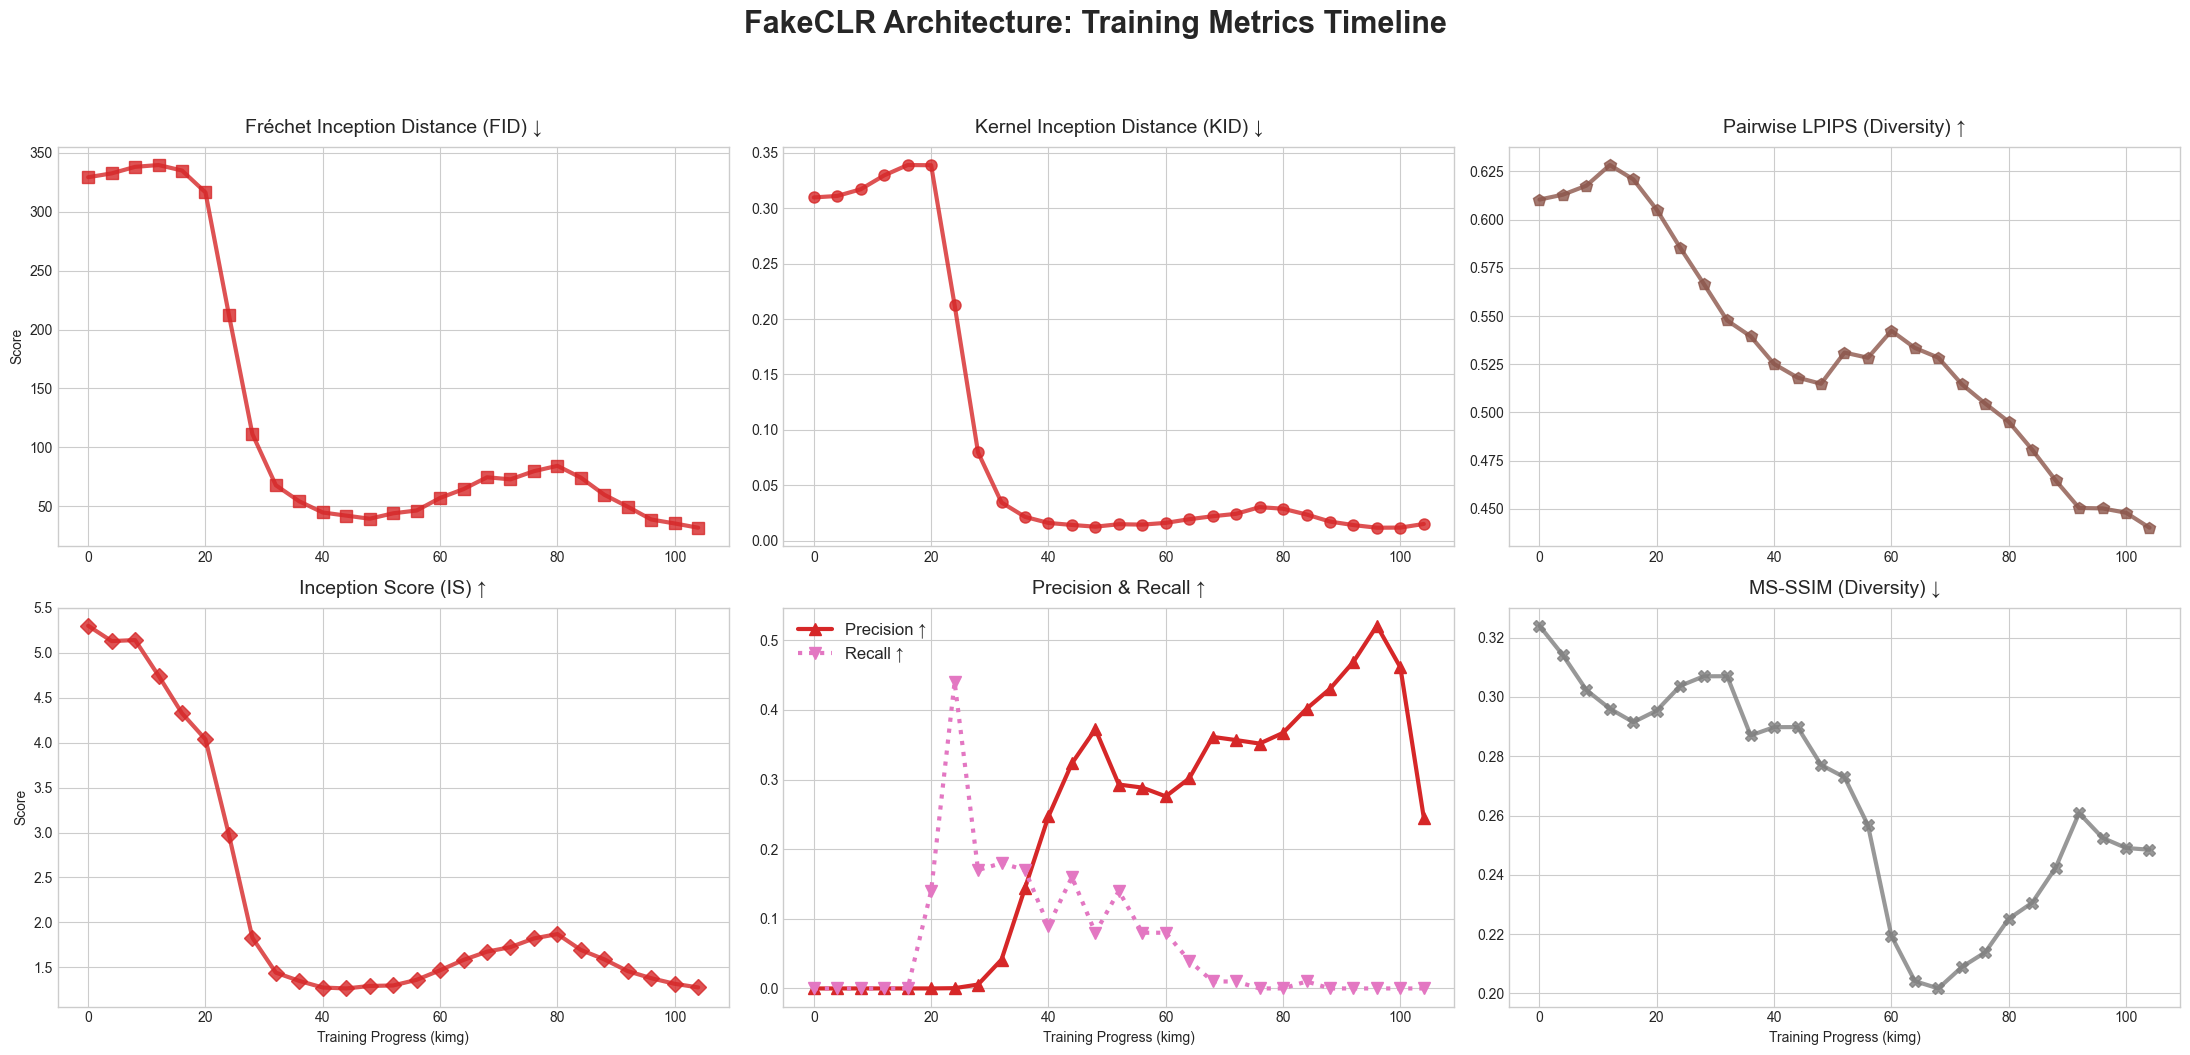


 FINAL METRIC RESULTS (Last Recorded Snapshot)
   ► FID Score         :  31.8215
   ► KID Score         :  0.0149
   ► Inception Score   :  1.2773
   ► Precision         :  0.2446
   ► Recall            :  0.0000
   ► LPIPS (Diversity) :  0.4403
   ► MS-SSIM Diversity :  0.2485


In [7]:
import os
import json
import csv
import matplotlib.pyplot as plt

# Configuration for FakeCLR
RUN_DIR = r"C:\Users\vishw\OneDrive\Desktop\Explo\FakeCLR\merged_snapshots"
COLOR = "#d62728" # Red theme for FakeCLR

plt.style.use('seaborn-v0_8-whitegrid')

# 1. Load Standard JSONL Metrics
def load_metric(base_dir, metric_type):
    variants = {
        'kid': [('kid5k_full', ['kid5k_full']), ('kid50k_full', ['kid50k_full'])],
        'fid': [('fid5k_full', ['fid5k_full']), ('fid50k_full', ['fid50k_full'])],
        'pr':  [('pr5k3_full', ['pr5k3_full_precision', 'pr5k3_full_recall']), 
                ('pr50k3_full', ['pr50k3_full_precision', 'pr50k3_full_recall'])],
        'is':  [('is5k', ['is5k_mean']), ('is50k', ['is50k_mean'])]
    }
    data = {}
    for file_name, keys in variants[metric_type]:
        file_path = os.path.join(base_dir, f"metric-{file_name}.jsonl")
        if os.path.exists(file_path):
            with open(file_path, 'rt') as f:
                for line in f:
                    entry = json.loads(line)
                    pkl_name = os.path.basename(entry['snapshot_pkl'])
                    kimg = int(pkl_name.split('-')[-1].split('.')[0])
                    
                    if metric_type == 'kid': data[kimg] = {'score': entry['results'][keys[0]]}
                    if metric_type == 'fid': data[kimg] = {'score': entry['results'][keys[0]]}
                    if metric_type == 'pr':  data[kimg] = {'precision': entry['results'][keys[0]], 'recall': entry['results'][keys[1]]}
                    if metric_type == 'is':  data[kimg] = {'score': entry['results'][keys[0]]}
            return data 
    return data

# 2. Load Custom CSV Metrics (LPIPS & MS-SSIM)
def load_custom_csv(file_path, value_col):
    data = {}
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                data[int(row['kimg'])] = {'score': float(row[value_col])}
    return data

def extract_xy(data_dict, key):
    sorted_kimgs = sorted(data_dict.keys())
    return sorted_kimgs, [data_dict[k][key] for k in sorted_kimgs]

# Load all data for FakeCLR
metrics = {
    'kid': load_metric(RUN_DIR, 'kid'),
    'fid': load_metric(RUN_DIR, 'fid'),
    'pr':  load_metric(RUN_DIR, 'pr'),
    'is':  load_metric(RUN_DIR, 'is'),
    'lpips': load_custom_csv(os.path.join(RUN_DIR, "custom_lpips_metrics.csv"), "lpips_avg"),
    'msssim': load_custom_csv(os.path.join(RUN_DIR, "custom_msssim_metrics.csv"), "msssim_avg")
}

# --- PLOTTING (Expanded to 2x3 Grid) ---
fig, axs = plt.subplots(2, 3, figsize=(22, 10))
fig.suptitle("FakeCLR Architecture: Training Metrics Timeline", fontsize=22, fontweight='bold', y=1.05)

# [Row 0, Col 0] FID
if metrics['fid']:
    x, y = extract_xy(metrics['fid'], 'score')
    axs[0, 0].plot(x, y, marker='s', markersize=8, linewidth=3, color=COLOR, alpha=0.8)
    axs[0, 0].set_title('Fréchet Inception Distance (FID) ↓', fontsize=14, pad=10)
    axs[0, 0].set_ylabel('Score')

# [Row 0, Col 1] KID
if metrics['kid']:
    x, y = extract_xy(metrics['kid'], 'score')
    axs[0, 1].plot(x, y, marker='o', markersize=8, linewidth=3, color=COLOR, alpha=0.8)
    axs[0, 1].set_title('Kernel Inception Distance (KID) ↓', fontsize=14, pad=10)

# [Row 0, Col 2] LPIPS
if metrics['lpips']:
    x, y = extract_xy(metrics['lpips'], 'score')
    axs[0, 2].plot(x, y, marker='p', markersize=9, linewidth=3, color='#8c564b', alpha=0.8)
    axs[0, 2].set_title('Pairwise LPIPS (Diversity) ↑', fontsize=14, pad=10)

# [Row 1, Col 0] IS
if metrics['is']:
    x, y = extract_xy(metrics['is'], 'score')
    axs[1, 0].plot(x, y, marker='D', markersize=8, linewidth=3, color=COLOR, alpha=0.8)
    axs[1, 0].set_title('Inception Score (IS) ↑', fontsize=14, pad=10)
    axs[1, 0].set_xlabel('Training Progress (kimg)')
    axs[1, 0].set_ylabel('Score')

# [Row 1, Col 1] Precision & Recall
if metrics['pr']:
    x_p, y_p = extract_xy(metrics['pr'], 'precision')
    x_r, y_r = extract_xy(metrics['pr'], 'recall')
    axs[1, 1].plot(x_p, y_p, marker='^', markersize=8, linestyle='-', linewidth=3, color=COLOR, label="Precision ↑")
    axs[1, 1].plot(x_r, y_r, marker='v', markersize=8, linestyle=':', linewidth=3, color='#e377c2', label="Recall ↑")
    axs[1, 1].set_title('Precision & Recall ↑', fontsize=14, pad=10)
    axs[1, 1].set_xlabel('Training Progress (kimg)')
    axs[1, 1].legend(fontsize=12)

# [Row 1, Col 2] MS-SSIM
if metrics['msssim']:
    x, y = extract_xy(metrics['msssim'], 'score')
    axs[1, 2].plot(x, y, marker='X', markersize=9, linewidth=3, color='#7f7f7f', alpha=0.8)
    axs[1, 2].set_title('MS-SSIM (Diversity) ↓', fontsize=14, pad=10)
    axs[1, 2].set_xlabel('Training Progress (kimg)')

plt.tight_layout()
plt.show()

# --- PRINT FINAL VALUES ---
print("\n" + "="*60)
print(" FINAL METRIC RESULTS (Last Recorded Snapshot)")
print("="*60)

if metrics['fid']:
    _, last_val = extract_xy(metrics['fid'], 'score')
    print(f"   ► FID Score         :  {last_val[-1]:.4f}")
if metrics['kid']:
    _, last_val = extract_xy(metrics['kid'], 'score')
    print(f"   ► KID Score         :  {last_val[-1]:.4f}")
if metrics['is']:
    _, last_val = extract_xy(metrics['is'], 'score')
    print(f"   ► Inception Score   :  {last_val[-1]:.4f}")
if metrics['pr']:
    _, last_p = extract_xy(metrics['pr'], 'precision')
    _, last_r = extract_xy(metrics['pr'], 'recall')
    print(f"   ► Precision         :  {last_p[-1]:.4f}")
    print(f"   ► Recall            :  {last_r[-1]:.4f}")
if metrics['lpips']:
    _, last_val = extract_xy(metrics['lpips'], 'score')
    print(f"   ► LPIPS (Diversity) :  {last_val[-1]:.4f}")
if metrics['msssim']:
    _, last_val = extract_xy(metrics['msssim'], 'score')
    print(f"   ► MS-SSIM Diversity :  {last_val[-1]:.4f}")
print("="*60)

## Part 2: Qualitative Analysis (Visual Evolution)

Chronological visual assessment using a fixed latent vector (`z`). Displays the structural evolution and texture mapping across saved network snapshots in a dynamic grid layout.

Found 27 snapshots. Generating sequence... (Output muted for clean rendering)


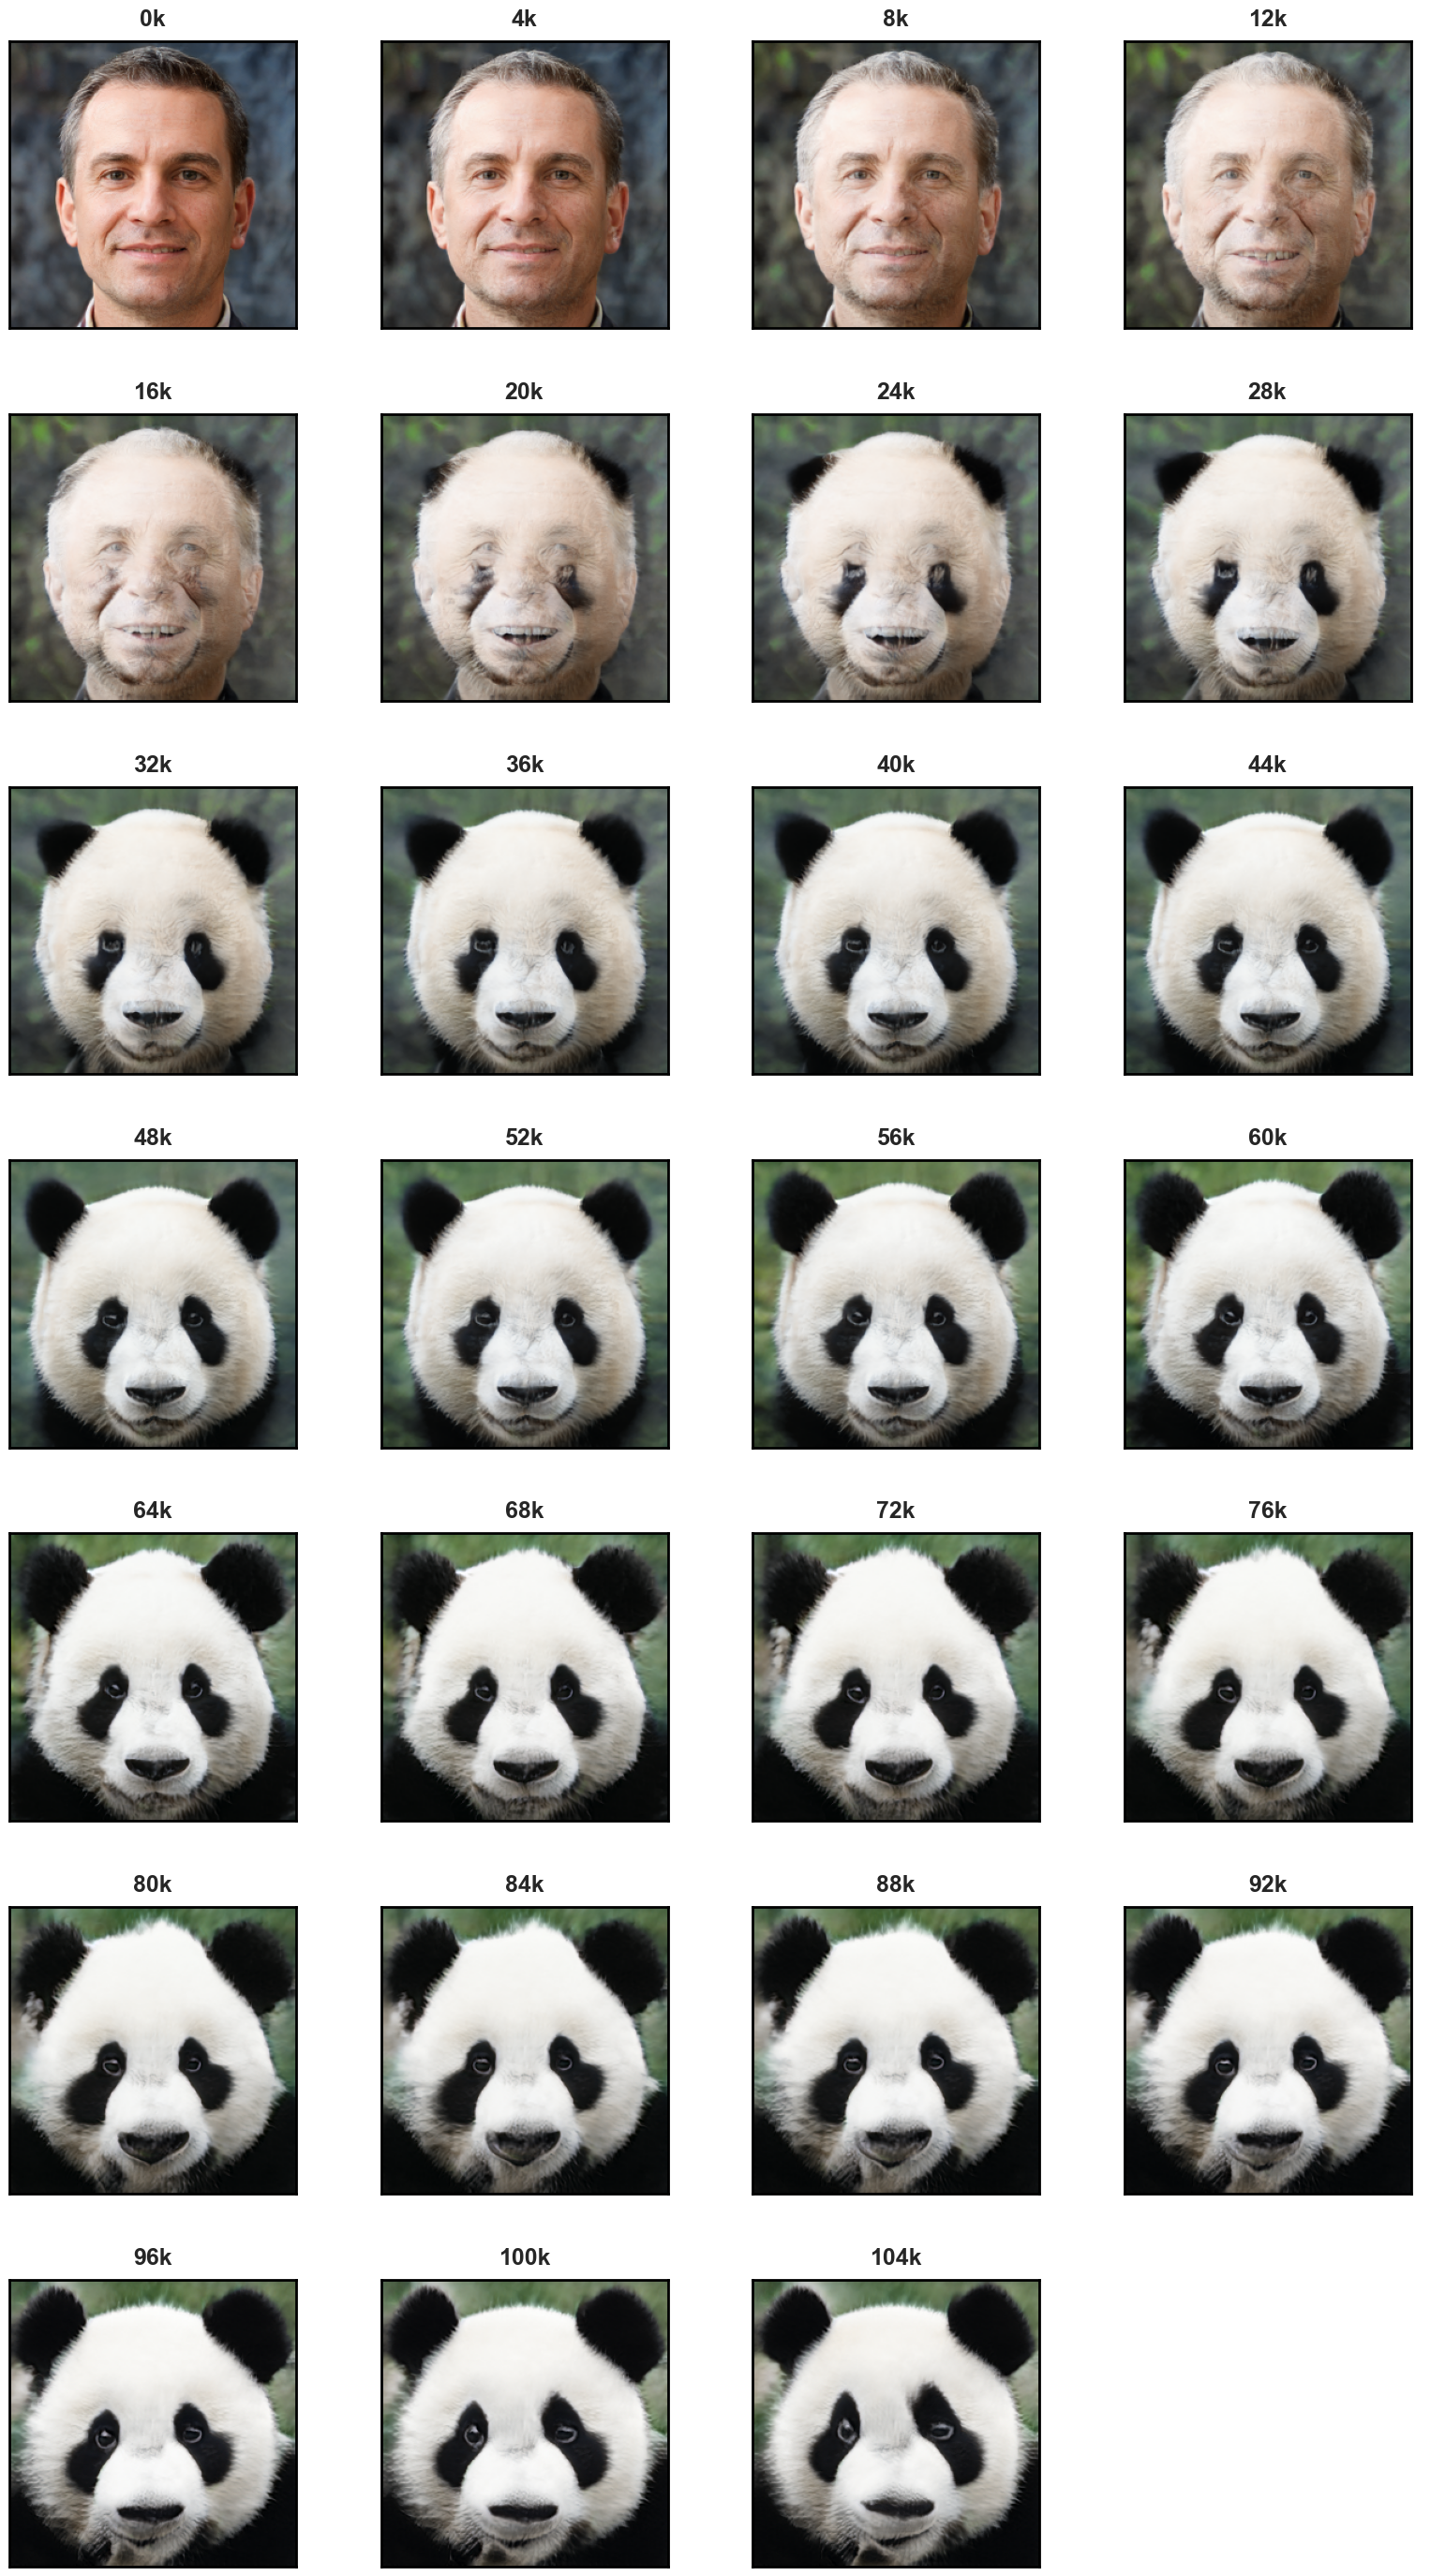

In [8]:
import math

# Find all network snapshots
snapshots = sorted(glob.glob(os.path.join(RUN_DIR, 'network-snapshot-*.pkl')))
print(f"Found {len(snapshots)} snapshots. Generating sequence... (Output muted for clean rendering)")

# Fixed seed
torch.manual_seed(42)
fixed_z = torch.randn([1, 512], device=device)
c = None 

evolution_images = []
snapshot_labels = []

# Mute standard outputs to hide compiler warnings during inference
with open(os.devnull, 'w') as devnull:
    old_stdout, old_stderr = sys.stdout, sys.stderr
    try:
        sys.stdout, sys.stderr = devnull, devnull
        for pkl_path in snapshots:
            snapshot_num = int(os.path.basename(pkl_path).replace('network-snapshot-', '').replace('.pkl', ''))
            
            with dnnlib.util.open_url(pkl_path) as f:
                G = legacy.load_network_pkl(f)['G_ema'].to(device)
            
            with torch.no_grad():
                img_tensor = G(fixed_z, c, truncation_psi=0.7, noise_mode='const')
                
            img_tensor = (img_tensor.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8)
            evolution_images.append(img_tensor[0].cpu().numpy())
            snapshot_labels.append(f"{snapshot_num}k")
    finally:
        sys.stdout, sys.stderr = old_stdout, old_stderr

# --- PLOTTING THE TIMELINE (LARGE GRID WRAPPING) ---
num_snaps = len(evolution_images)
cols = 4
rows = math.ceil(num_snaps / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))

if rows * cols == 1:
    axes = np.array([axes])
axes_flat = axes.flatten()

for i, (img, label) in enumerate(zip(evolution_images, snapshot_labels)):
    ax = axes_flat[i]
    ax.imshow(img)
    ax.set_title(label, fontsize=18, fontweight='bold', pad=12)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.show()